# Five-layer architecture: interface examples

This notebook is the executable usage guide for the modular architecture. The raw and standard data layers are implemented; later sections define the intended public interfaces.

## 1. Raw data layer

`RawDataManager` reads source metadata from a catalog, resolves paths under `data/`, and reports availability without interpreting source-specific columns. `source_id` is a stable dataset key, not a dynamically generated Python variable.

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt

from src.raw import RawDataManager
from src.standard import DATASET_IDS, StandardDataManager, time_bounds

project_root = Path.cwd()
data_root = project_root / "data"
catalog_path = project_root / "config/raw_data_sources.csv"

In [2]:
raw_data = RawDataManager(catalog_path, data_root)
display(raw_data.catalog)

,source_id,domain,provider,acquisition_method,file_format,local_path,source_url,download_url,api_url,remote_file_name,version,checksum_algorithm,expected_checksum,required,description,download_instructions,options_json
source_id,,,,,,,,,,,,,,,,,
osm_china_pbf,osm_china_pbf,network,Geofabrik/direct OSM export,direct,pbf,osm/china-latest.osm.pbf,https://download.geofabrik.de/asia/china.html,https://download.geofabrik.de/asia/china-lates...,,china-latest.osm.pbf,latest,,,<NA>,Complete China OpenStreetMap extract used to d...,Automatic: prepare downloads the current china...,{}
gem_integrated_power,gem_integrated_power,generation,Global Energy Monitor,manual,xlsx,Global-Integrated-Power-March-2026-II.xlsx,https://globalenergymonitor.org/projects/globa...,,,Global-Integrated-Power-March-2026-II.xlsx,March 2026,,,<NA>,Unit- and phase-level global power project rec...,"Manual: open the GEM page, select Download dat...",{}
doe_storage,doe_storage,storage,Sandia National Laboratories,manual,json,doe_global_energy_storage_database_2022.json,https://gesdb.sandia.gov/projects.html,,,doe_global_energy_storage_database_2022.json,2022,,,<NA>,Project-level global energy storage database e...,"Manual: open the Sandia GESDB project page, ac...",{}
provincial_hourly_load,provincial_hourly_load,load,Figshare,figshare_api,xlsx,china_provincial_hourly_load_2015_2024.xlsx,https://doi.org/10.6084/m9.figshare.29832701,,https://api.figshare.com/v2/articles/29832701,Data output.xlsx,2015-2024,md5,bf730a545bc297b20d6a7ff93571992a,<NA>,China provincial synthetic hourly load workbook.,Automatic: prepare resolves Data output.xlsx t...,{}
worldpop_population,worldpop_population,population,WorldPop,direct,tif,chn_ppp_2020_1km_aggregated_unadj.tif,https://data.worldpop.org/GIS/Population/Globa...,https://data.worldpop.org/GIS/Population/Globa...,,chn_ppp_2020_1km_Aggregated_UNadj.tif,2020,,,<NA>,UN-adjusted one-kilometre population raster fo...,Automatic: prepare downloads the GeoTIFF direc...,{}
era5_china_2024,era5_china_2024,weather,Copernicus Climate Data Store,atlite_cds,nc,capacity-factors/era5_china_2024.nc,https://cds.climate.copernicus.eu/datasets/rea...,,,,2024,,,<NA>,ERA5 China cutout containing weather fields re...,"API: create a CDS account, accept the ERA5 lic...","{""year"":2024,""x"":[73.0,136.0],""y"":[18.0,54.0],..."
province_boundaries,province_boundaries,administrative_boundary,DataV,direct,geojson,china_provinces_datav_original.geojson,https://geo.datav.aliyun.com/areas_v3/bound/10...,https://geo.datav.aliyun.com/areas_v3/bound/10...,,100000_full.json,current,,,<NA>,Original province boundary GeoJSON before geom...,Automatic: prepare downloads the original prov...,{}
pypsa_technology_costs,pypsa_technology_costs,technology_cost,PyPSA technology-data,direct,csv,pypsa_technology_data_costs_2025.csv,https://github.com/PyPSA/technology-data,https://raw.githubusercontent.com/PyPSA/techno...,,costs_2025.csv,2025,,,<NA>,Upstream technology-data cost and efficiency a...,Automatic: prepare downloads outputs/costs_202...,{}
cec_yearbook,cec_yearbook,official_statistics,China Electricity Council,manual,pdf,cec_china_electric_power_statistics_yearbook_2...,,,,cec_china_electric_power_statistics_yearbook_2...,2024,,,<NA>,Authorized China Electric Power Statistics Yea...,Manual: obtain the authorized 2024 yearbook PD...,{}


In [3]:
all_sources = raw_data.check()
display(all_sources)

,domain,provider,acquisition_method,file_format,local_path,detected_path,required,exists,size_bytes,checksum,status,download_instructions
source_id,,,,,,,,,,,,
osm_china_pbf,network,Geofabrik/direct OSM export,direct,pbf,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,1560217727,,available,Automatic: prepare downloads the current china...
gem_integrated_power,generation,Global Energy Monitor,manual,xlsx,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,23337385,,available,"Manual: open the GEM page, select Download dat..."
doe_storage,storage,Sandia National Laboratories,manual,json,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,7436775,,available,"Manual: open the Sandia GESDB project page, ac..."
provincial_hourly_load,load,Figshare,figshare_api,xlsx,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,41867984,bf730a545bc297b20d6a7ff93571992a,available,Automatic: prepare resolves Data output.xlsx t...
worldpop_population,population,WorldPop,direct,tif,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,49445858,,available,Automatic: prepare downloads the GeoTIFF direc...
era5_china_2024,weather,Copernicus Climate Data Store,atlite_cds,nc,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,False,<NA>,,credentials_required,"API: create a CDS account, accept the ERA5 lic..."
province_boundaries,administrative_boundary,DataV,direct,geojson,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,582522,,available,Automatic: prepare downloads the original prov...
pypsa_technology_costs,technology_cost,PyPSA technology-data,direct,csv,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,281386,,available,Automatic: prepare downloads outputs/costs_202...
cec_yearbook,official_statistics,China Electricity Council,manual,pdf,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,3693366,,available,Manual: obtain the authorized 2024 yearbook PD...


In [4]:
all_data = raw_data.prepare(source_ids=["province_boundaries", "pypsa_technology_costs"])
display(all_data)

,domain,provider,acquisition_method,file_format,local_path,detected_path,required,exists,size_bytes,checksum,status,download_instructions,action,error
source_id,,,,,,,,,,,,,,
province_boundaries,administrative_boundary,DataV,direct,geojson,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,582522,,available,Automatic: prepare downloads the original prov...,already_available,<NA>
pypsa_technology_costs,technology_cost,PyPSA technology-data,direct,csv,/Users/jiang/Documents/Codex/nature-plan-paper...,<NA>,NaN,True,281386,,available,Automatic: prepare downloads outputs/costs_202...,already_available,<NA>


## 2. Standard data layer

`StandardDataManager` exposes the stable dataset IDs `spatial`, `network`, `generation`, `storage`, `parameter`, `load`, `population`, and `resource`. Source-specific processing is controlled by `config/standard_data.toml`; changing source dependencies does not change these public IDs.

In [5]:
standard_data = StandardDataManager(
    project_root / "config/standard_data.toml",
    raw_data=raw_data,
)
display(standard_data.check())

,processor,source_ids,sources_available,source_status,outputs,output_available
dataset_id,,,,,,
spatial,spatial,"(province_boundaries,)",True,province_boundaries:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
network,network,"(osm_china_pbf,)",True,osm_china_pbf:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
generation,generation,"(gem_integrated_power,)",True,gem_integrated_power:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
storage,storage,"(gem_integrated_power, doe_storage)",True,gem_integrated_power:available; doe_storage:av...,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
parameter,parameter,"(pypsa_technology_costs,)",True,pypsa_technology_costs:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
load,load,"(provincial_hourly_load,)",True,provincial_hourly_load:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
population,population,"(worldpop_population,)",True,worldpop_population:available,(/Users/jiang/Documents/Codex/nature-plan-pape...,True
resource,resource,"(era5_china_2024,)",False,era5_china_2024:credentials_required,(/Users/jiang/Documents/Codex/nature-plan-pape...,False


In [51]:
_id = "parameter"
standard_data.schema(_id)
# show_data = standard_data.load(_id)
# show_data

,dataset_id,component,role,name,dimensions,dtype,size,required,description,value
0,parameter,data,dimension,row,<NA>,<NA>,1443,False,Number of records in the table.,NaN
1,parameter,data,column,uid,row,large_string[pyarrow],1443,True,Globally unique identifier for the standardize...,NaN
2,parameter,data,column,applies_to_dataset,row,large_string[pyarrow],1443,True,Dataset to which the parameter applies.,NaN
3,parameter,data,column,applies_to_uid,row,large_string[pyarrow],1443,True,Optional UID of the specific object to which i...,NaN
4,parameter,data,column,class,row,large_string[pyarrow],1443,True,Primary standardized category.,NaN
5,parameter,data,column,subclass,row,large_string[pyarrow],1443,True,"More specific, extensible standardized category.",NaN
6,parameter,data,column,status,row,large_string[pyarrow],1443,True,Lifecycle or operating status.,NaN
7,parameter,data,column,observed_at,row,large_string[pyarrow],1443,True,Time at which the source record was observed.,NaN
8,parameter,data,column,valid_from,row,large_string[pyarrow],1443,True,Inclusive start of the record's validity.,NaN
9,parameter,data,column,valid_to,row,large_string[pyarrow],1443,True,End of the record's validity.,NaN


In [28]:
# build() regenerates a dataset; load() reads an existing standard artifact.
generation = standard_data.load("generation")
network = standard_data.load("network")
storage = standard_data.load("storage")
parameter = standard_data.load("parameter")
generation.schema()

,component,role,name,dimensions,dtype,size,value
0,data,dimension,row,<NA>,<NA>,39388,NaN
1,data,column,uid,row,large_string[pyarrow],39388,NaN
2,data,column,type,row,large_string[pyarrow],39388,NaN
3,data,column,technology,row,large_string[pyarrow],39388,NaN
4,data,column,status,row,large_string[pyarrow],39388,NaN
5,data,column,voltage_kv,row,list<element: double>[pyarrow],39388,NaN
6,data,column,valid_from,row,large_string[pyarrow],39388,NaN
7,data,column,valid_to,row,large_string[pyarrow],39388,NaN
8,data,column,observed_at,row,large_string[pyarrow],39388,NaN
9,data,column,source_id,row,large_string[pyarrow],39388,NaN


In [56]:
spatial = standard_data.load("spatial")
display(spatial.head())

,uid,type,technology,status,voltage_kv,valid_from,valid_to,observed_at,source_id,source_record_id,geometry_method,name,parent_uid,geometry
0,datav:province:110000,province,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,province_boundaries,110000,source_geometry,北京市,<NA>,GEOMETRYCOLLECTION (POLYGON ((115.72068 39.551...
1,datav:province:120000,province,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,province_boundaries,120000,source_geometry,天津市,<NA>,GEOMETRYCOLLECTION (POLYGON ((117.8506 39.3639...
2,datav:province:130000,province,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,province_boundaries,130000,source_geometry,河北省,<NA>,GEOMETRYCOLLECTION (MULTIPOLYGON (((118.86936 ...
3,datav:province:140000,province,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,province_boundaries,140000,source_geometry,山西省,<NA>,"MULTIPOLYGON (((110.37926 34.60061, 110.42484 ..."
4,datav:province:150000,province,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,province_boundaries,150000,source_geometry,内蒙古自治区,<NA>,"POLYGON ((97.1729 42.79526, 97.37124 42.45708,..."


In [30]:
load = standard_data.load("load")
if standard_data.check("resource").loc["resource", "sources_available"]:
    resource = standard_data.build("resource")
    display(resource)
else:
    print("resource: raw ERA5 cutout is unavailable; build skipped.")

FileNotFoundError: resource is missing raw sources: ['era5_china_2024']

### Representative dataset plots

`plot()` returns one representative Matplotlib figure for quality control and never writes a file. The load example uses 2024; datasets without a built standard artifact are reported and skipped.

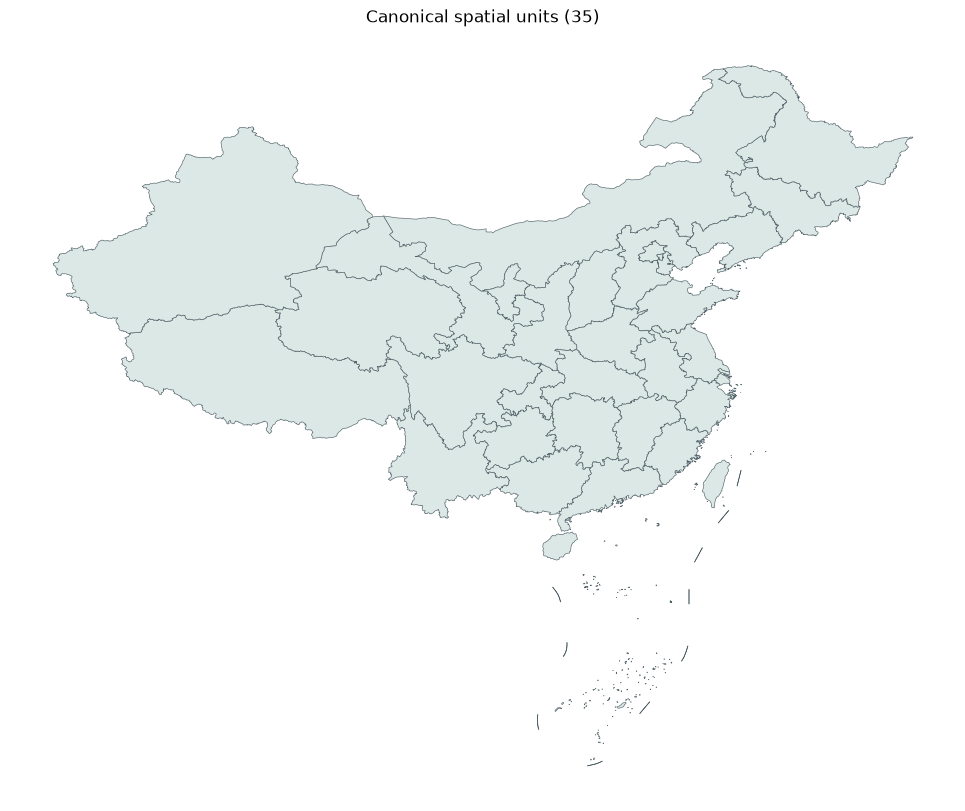

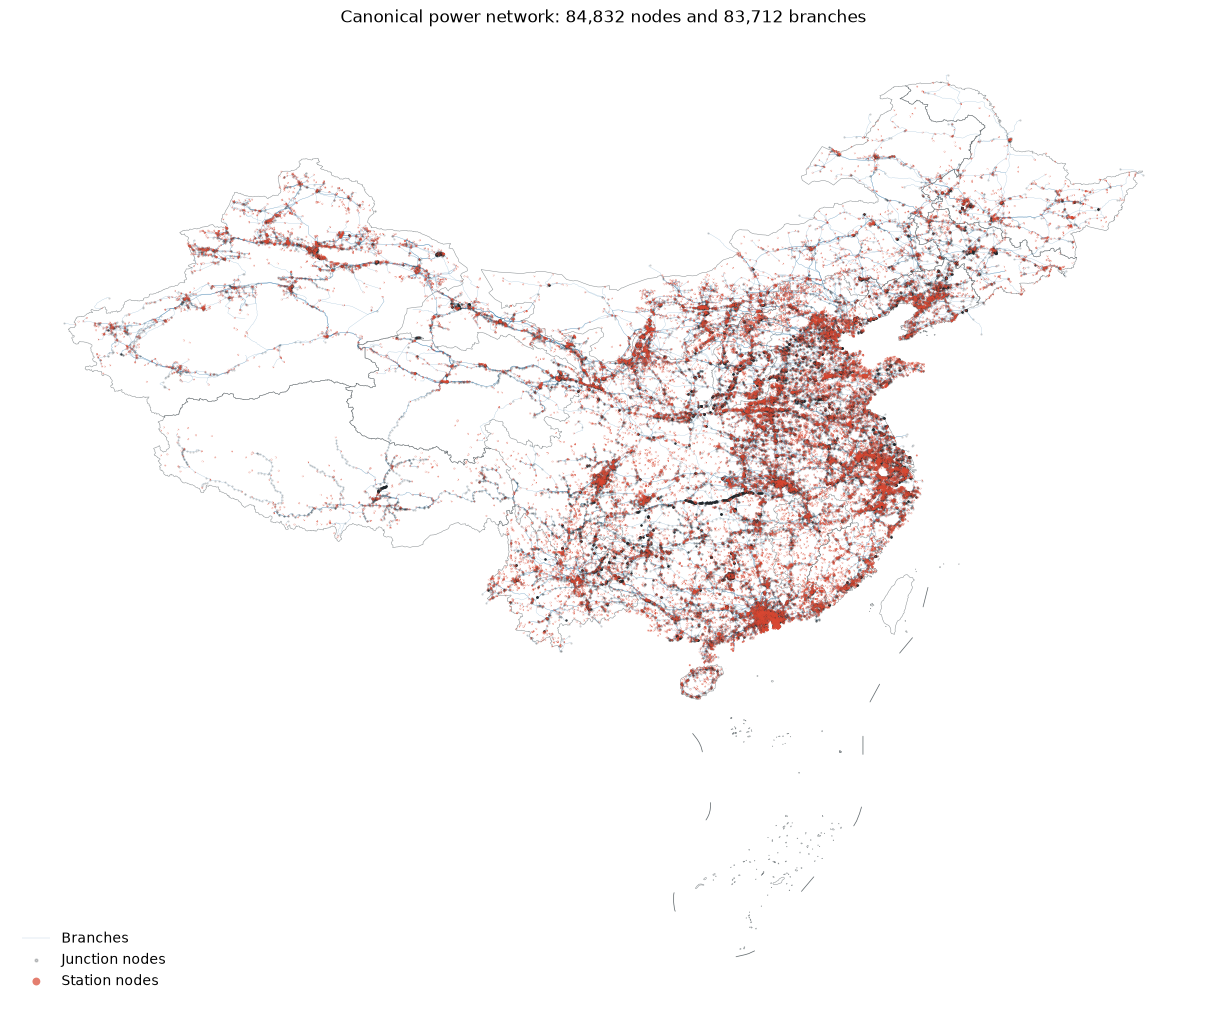

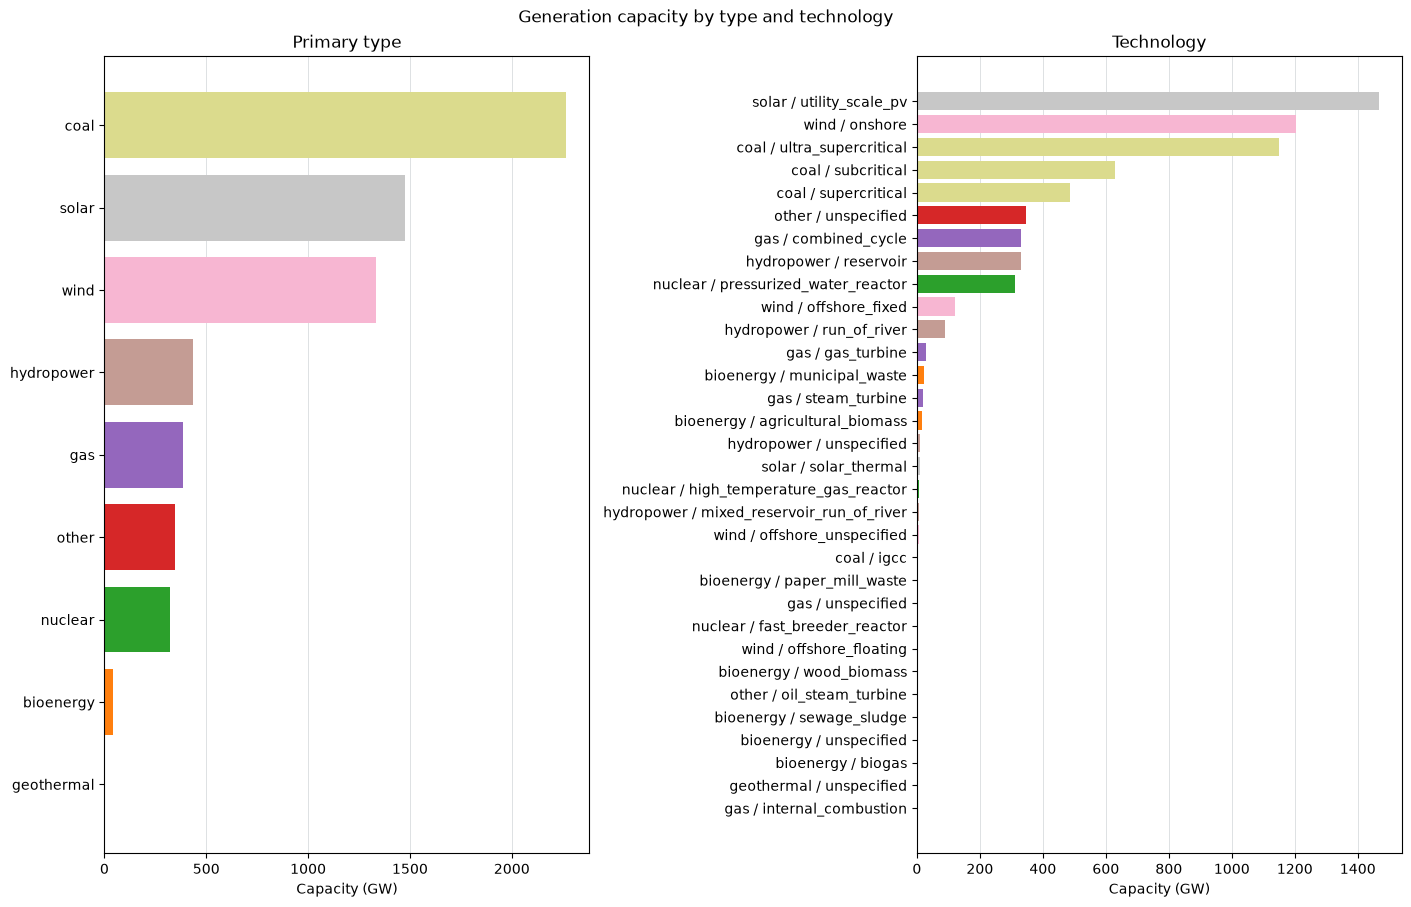

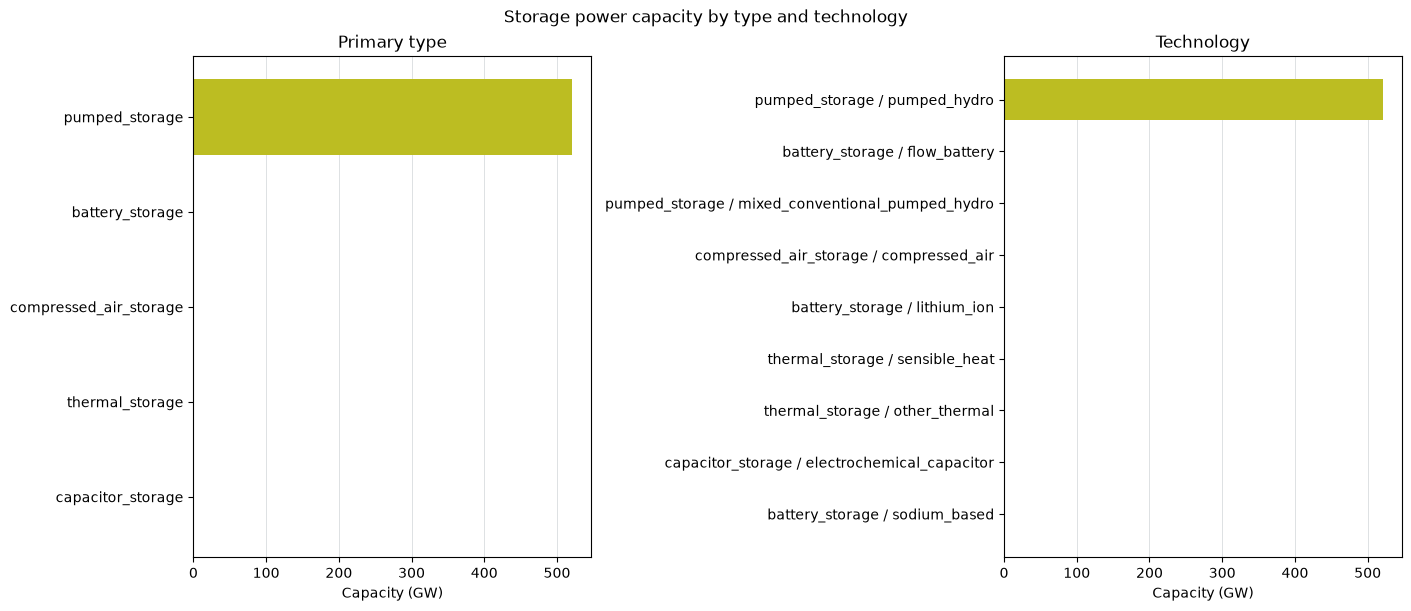

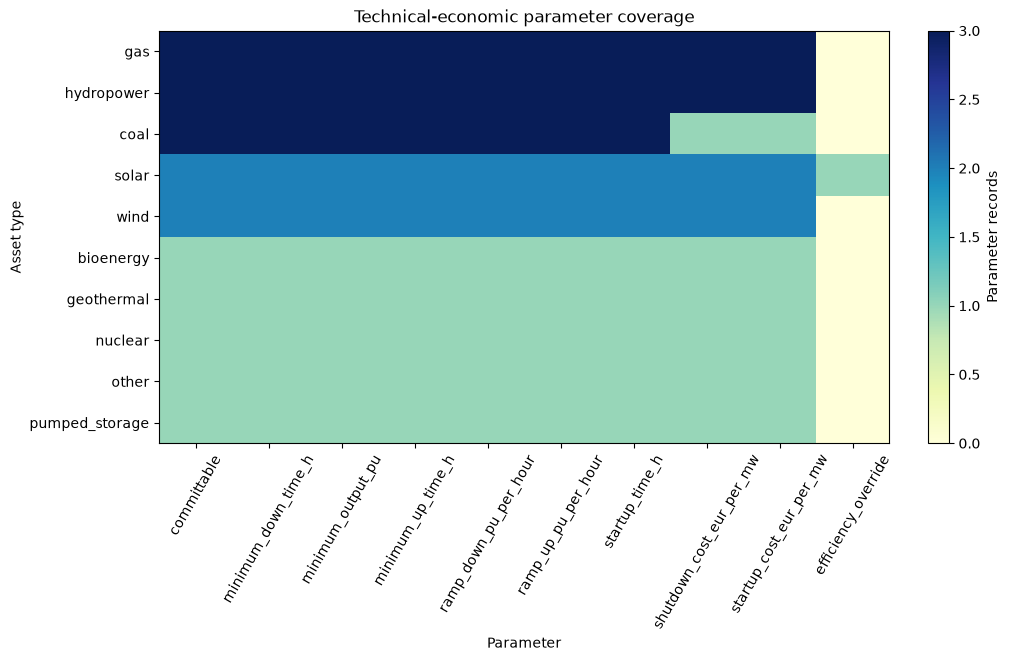

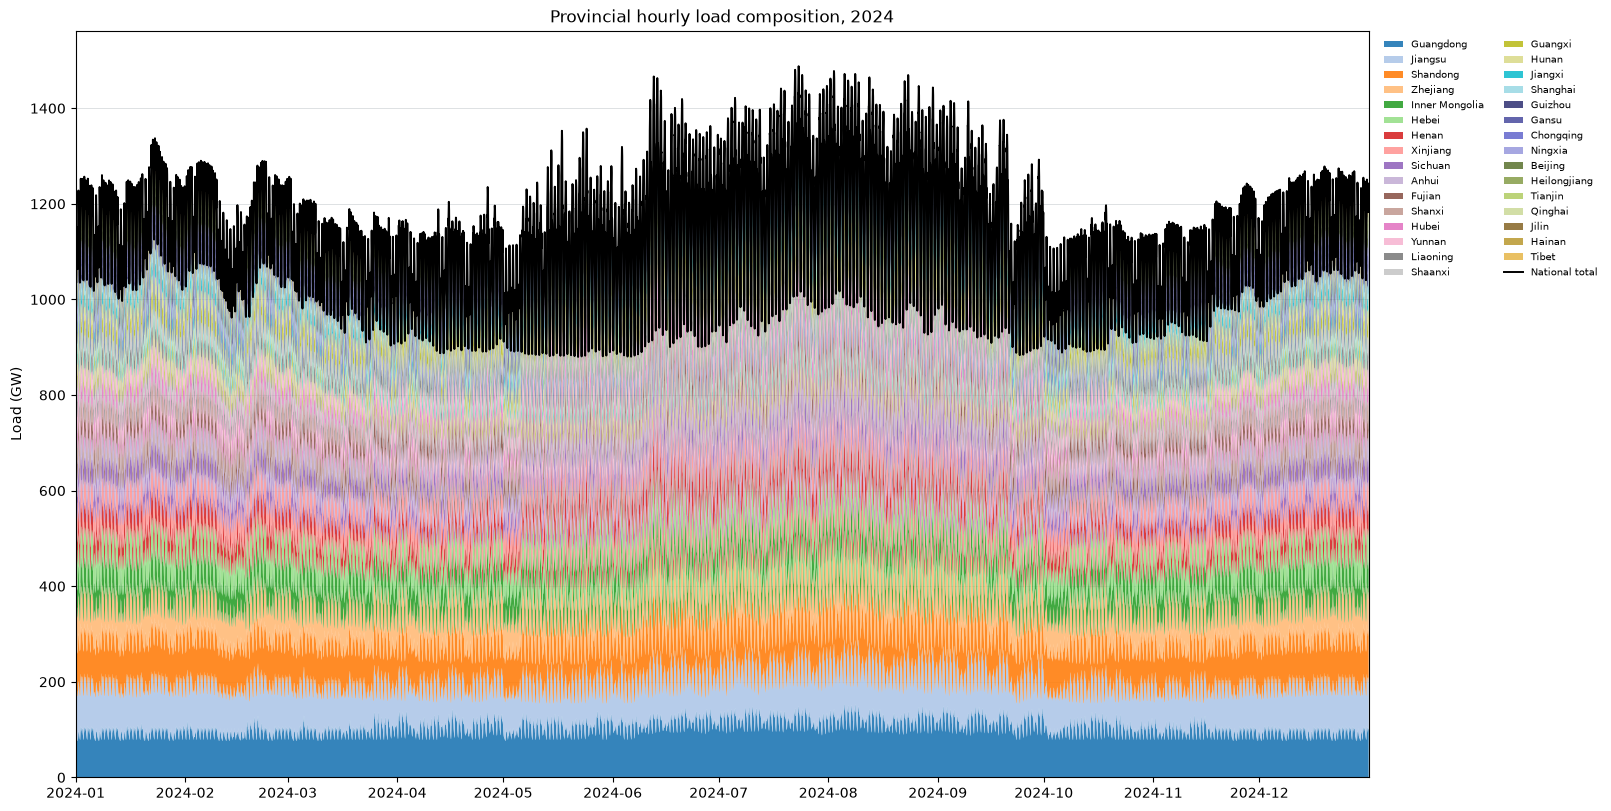

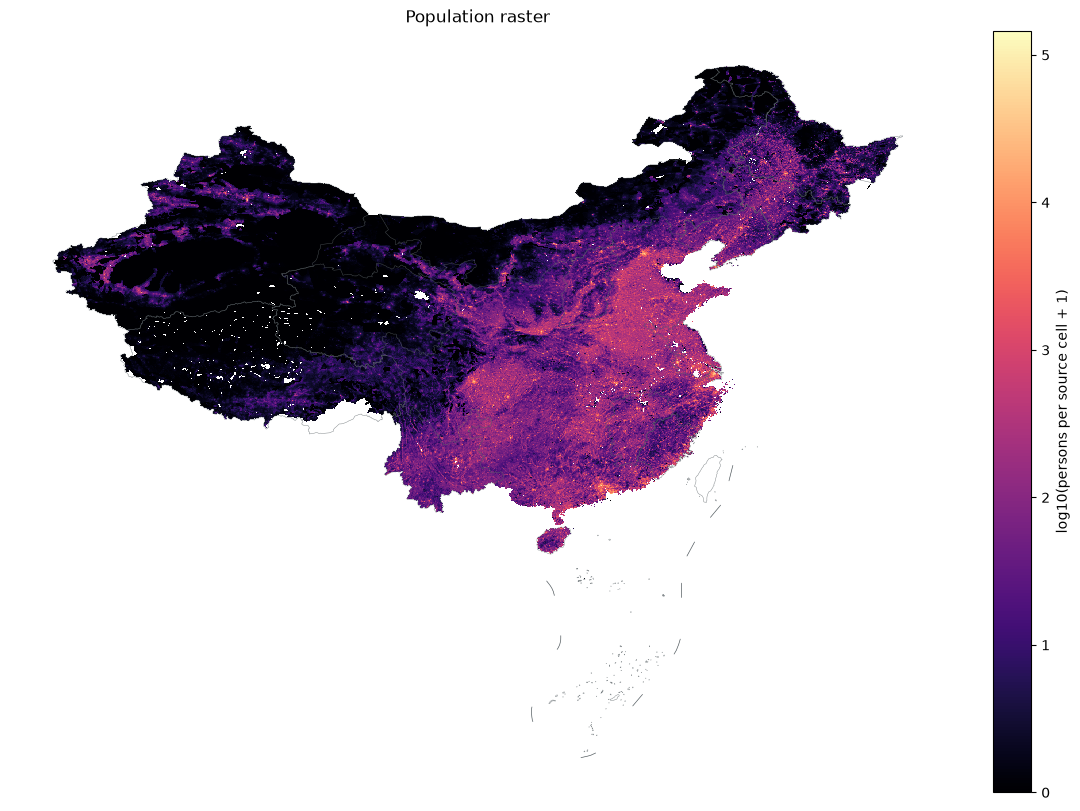

resource: standard output is not built; plot skipped.


In [8]:
_dataset_status = standard_data.check()
_plot_options = {"load": {"year": 2024}}

for _dataset_id in DATASET_IDS:
    if not _dataset_status.loc[_dataset_id, "output_available"]:
        print(f"{_dataset_id}: standard output is not built; plot skipped.")
        continue
    _figure = standard_data.plot(
        _dataset_id,
        **_plot_options.get(_dataset_id, {}),
    )
    display(_figure)
    plt.close(_figure)

## 3. Spatiotemporal mapping layer (planned interface)

Input: canonical assets, spatial units, and time coordinates. Output: explicit mapping tables such as `generation_node_mapping` and `load_cell_node_mapping`, including method, distance, confidence, and review flags. Typical usage will be `mappings = SpatiotemporalMapping(standard_data, mapping_config).build()`.

## 4. System case layer (planned interface)

Input: canonical data, mappings, and a scenario configuration. Output: one validated `PowerSystemCase` containing static asset tables and aligned time-series arrays. Typical usage will be `case = SystemCaseBuilder(standard_data, mappings).build(case_config)`.

## 5. Application layer (planned interface)

Input: `PowerSystemCase` plus formulation and solver options. Output: standardized model results without mutating the case. Typical usage will be `result = UnitCommitmentApplication(application_config).solve(case)`; OPF and planning applications will consume the same case contract.